# Preprocessing Verification

This notebook keeps `src/preprocess.py` as the real source of truth.

The notebook mirrors the same preprocessing steps, prints what happens at each step, and plots the intermediate results so you can verify the pipeline visually.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.append(str(repo_root))

from src.preprocess import prepare_datasets, _filter_unreadable_images, _get_image_paths

/Users/luannguyen/PersonalProjects/garbage-material-classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Use the same settings as preprocess.py.
data_dir = str(repo_root / "data" / "RealWaste")
image_size = (224, 224)
batch_size = 32
model_type = "cnn"  # change to "cnn" if needed
val_size = 0.1
test_size = 0.1
random_state = 42

## 1. Inspect Folder Structure And Class Counts

In [3]:
image_paths, labels, class_names, class_counts = _get_image_paths(data_dir)

print("Classes:", class_names)
print("Class counts:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")
print("Total images before filtering:", len(image_paths))

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class counts:
  Cardboard: 461
  Food Organics: 411
  Glass: 420
  Metal: 790
  Miscellaneous Trash: 495
  Paper: 500
  Plastic: 921
  Textile Trash: 318
  Vegetation: 436
Total images before filtering: 4752


- The class counts add up to `4752`, so the folder scan is consistent.
- This step proves the dataset structure is readable and each class folder is being found correctly.

## 2. Remove Or Flag Unreadable Images

In [4]:
valid_image_paths, valid_labels, unreadable_files = _filter_unreadable_images(image_paths, labels)
valid_labels = np.array(valid_labels)

print("Unreadable files:", len(unreadable_files))
print("Total valid images after filtering:", len(valid_image_paths))

if unreadable_files:
    print("Unreadable file examples:")
    for path in unreadable_files[:5]:
        print(" ", path)

Unreadable files: 0
Total valid images after filtering: 4752


- `Unreadable files: 0` means no images were dropped during validation.
- If this number were greater than 0, those bad files would be excluded before splitting and training.

## 3. Stratified Train / Validation / Test Split

In [5]:
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    valid_image_paths,
    valid_labels,
    test_size=test_size,
    stratify=valid_labels,
    random_state=random_state,
)

val_ratio = val_size / (1 - test_size)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths,
    train_val_labels,
    test_size=val_ratio,
    stratify=train_val_labels,
    random_state=random_state,
)

print("Train size:", len(train_paths))
print("Validation size:", len(val_paths))
print("Test size:", len(test_paths))

Train size: 3800
Validation size: 476
Test size: 476


- `3800 / 476 / 476` is the correct 80/10/10 split of `4752` images.
- Because the split is stratified, each class should stay represented across train, validation, and test.

## 4. Pick One Sample Image

In [6]:
sample_path = train_paths[0]
sample_label = train_labels[0]

print("Sample path:", str(Path(sample_path).relative_to(repo_root)))
print("Sample class:", class_names[int(sample_label)])

Sample path: data/RealWaste/Metal/Metal_604.jpg
Sample class: Metal


- `Sample path: data/RealWaste/Metal/Metal_604.jpg` and `Sample class: Metal` match, which is what we want.
- This confirms the path and label stayed aligned after splitting.

## 5. Load Image And Force RGB

Raw image shape: (524, 524, 3)
RGB channels: 3


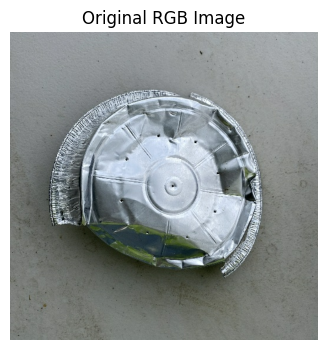

In [7]:
raw_bytes = tf.io.read_file(sample_path)
raw_image = tf.image.decode_image(raw_bytes, channels=3, expand_animations=False)

print("Raw image shape:", tuple(raw_image.shape))
print("RGB channels:", raw_image.shape[-1])

plt.figure(figsize=(4, 4))
plt.imshow(tf.cast(raw_image, tf.uint8).numpy())
plt.title("Original RGB Image")
plt.axis("off")
plt.show()

- The raw image shape is `(524, 524, 3)`, so this file was loaded successfully and already has 3 RGB channels.
- The displayed image should look natural here because no model-specific preprocessing has been applied yet.
- This is the clean reference image we compare against in later steps.


## 6. Resize To 224 x 224

Resized image shape: (224, 224, 3)
Resized image dtype: float32


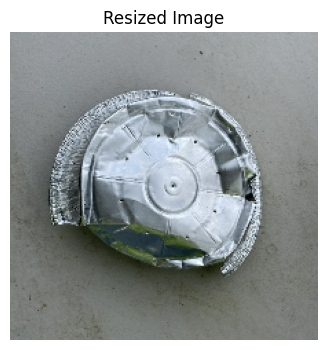

In [8]:
resized_image = tf.image.resize(raw_image, image_size)
resized_image = tf.cast(resized_image, tf.float32)

print("Resized image shape:", tuple(resized_image.shape))
print("Resized image dtype:", resized_image.dtype.name)

plt.figure(figsize=(4, 4))
plt.imshow(np.clip(resized_image.numpy() / 255.0, 0, 1))
plt.title("Resized Image")
plt.axis("off")
plt.show()

- The resized image shape is `(224, 224, 3)`, which matches the target size used in `preprocess.py`.
- The picture should still look normal here because resizing changes the size, not the semantic content.

## 7. Apply The Same Model-Specific Preprocessing As preprocess.py

Model type: cnn
Processed image shape: (224, 224, 3)
Processed image dtype: float32
Processed pixel min: 0.0
Processed pixel max: 1.0


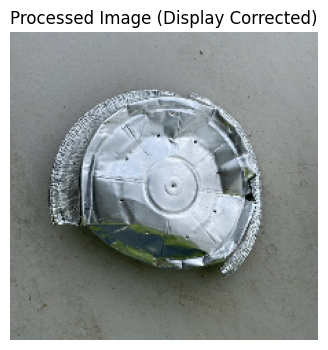

In [9]:
if model_type.lower() == "mobilenetv2":
    processed_image = mobilenet_preprocess(resized_image)
else:
    processed_image = resized_image / 255.0

def to_display_image(image, model_type):
    image = image.numpy() if tf.is_tensor(image) else np.asarray(image)
    if model_type.lower() == "mobilenetv2":
        image = (image + 1.0) / 2.0
    return np.clip(image, 0, 1)

print("Model type:", model_type)
print("Processed image shape:", tuple(processed_image.shape))
print("Processed image dtype:", processed_image.dtype.name)
print("Processed pixel min:", float(tf.reduce_min(processed_image).numpy()))
print("Processed pixel max:", float(tf.reduce_max(processed_image).numpy()))

plt.figure(figsize=(4, 4))
plt.imshow(to_display_image(processed_image, model_type))
plt.title("Processed Image (Display Corrected)")
plt.axis("off")
plt.show()

- For `mobilenetv2`, a processed pixel range near `-1.0` to `1.0` is exactly expected.
- The processed image may look darker or tinted when plotted, and that is normal because these values are meant for the model, not for human viewing.

## 8. Apply The Same Augmentation As preprocess.py

In [10]:
augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    # layers.RandomBrightness(0.2),
    # layers.RandomContrast(0.2),
])


def random_blur(image):
    if tf.random.uniform(()) > 0.5:
        image = tf.expand_dims(image, 0)
        image = tf.nn.avg_pool2d(image, ksize=3, strides=1, padding="SAME")
        image = tf.squeeze(image, 0)
    return image


aug_1 = random_blur(augmenter(processed_image, training=True))
aug_2 = random_blur(augmenter(processed_image, training=True))

print("Augmented image 1 shape:", tuple(aug_1.shape))
print("Augmented image 2 shape:", tuple(aug_2.shape))
print("Augmentation diff 1:", float(tf.reduce_mean(tf.abs(aug_1 - processed_image)).numpy()))
print("Augmentation diff 2:", float(tf.reduce_mean(tf.abs(aug_2 - processed_image)).numpy()))

Augmented image 1 shape: (224, 224, 3)
Augmented image 2 shape: (224, 224, 3)
Augmentation diff 1: 0.11591456085443497
Augmentation diff 2: 0.12379901856184006


- `Augmentation diff 1` and `Augmentation diff 2` are both greater than `0`, so augmentation actually changed the image.
- The augmented pictures should still show the same object, but with small random changes like flip, rotation, zoom, or translation.
- Small border artifacts or mirrored edges can happen after rotation/translation and are normal.

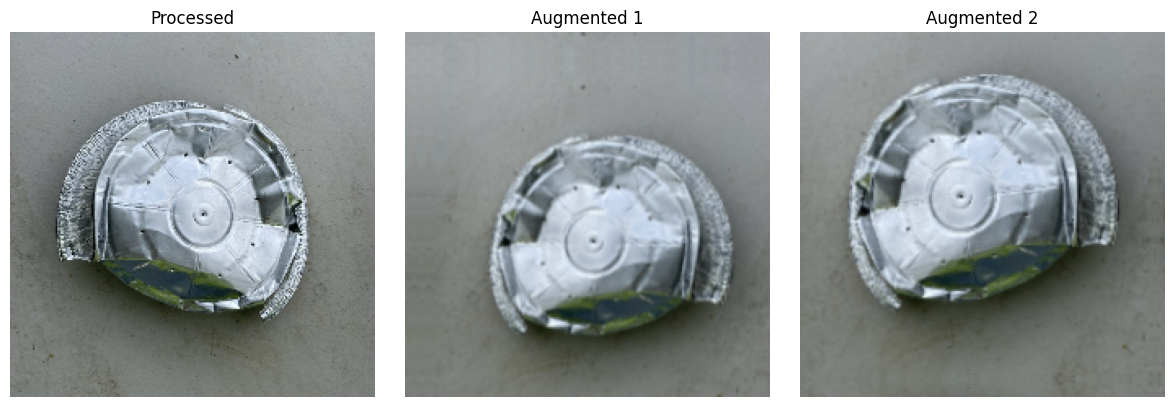

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_display_image(processed_image, model_type))
plt.title("Processed")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(to_display_image(aug_1, model_type))
plt.title("Augmented 1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(to_display_image(aug_2, model_type))
plt.title("Augmented 2")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Call prepare_datasets(...) And Verify The Actual Returned Data

In [12]:
data = prepare_datasets(
    data_dir=data_dir,
    image_size=image_size,
    batch_size=batch_size,
    model_type=model_type,
    val_size=val_size,
    test_size=test_size,
    random_state=random_state,
)

print("Returned keys:", list(data.keys()))
print("Returned class names:", data["class_names"])
print("Returned unreadable files:", len(data["unreadable_files"]))
print("Returned class weights:", data["class_weights"])

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class counts: {'Cardboard': 461, 'Food Organics': 411, 'Glass': 420, 'Metal': 790, 'Miscellaneous Trash': 495, 'Paper': 500, 'Plastic': 921, 'Textile Trash': 318, 'Vegetation': 436}
Unreadable files: 0
Train: 3800 | Val: 476 | Test: 476
Returned keys: ['train_ds', 'val_ds', 'test_ds', 'class_names', 'class_counts', 'class_weights', 'unreadable_files']
Returned class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Returned unreadable files: 0
Returned class weights: {0: 1.1442336645588678, 1: 1.2833502195204323, 2: 1.2566137566137565, 3: 0.6680731364275668, 4: 1.0689170182841068, 5: 1.0555555555555556, 6: 0.572893110206543, 7: 1.6622922134733158, 8: 1.2132822477650065}


- Calling `prepare_datasets(...)` returns the real pipeline outputs used for training.
- The returned keys, class names, unreadable file count, and class weights all look consistent with the earlier manual checks.

## 10. Inspect The Actual val_ds Output

`val_ds` should have resize + preprocessing, but no augmentation.

In [13]:
val_images, val_labels = next(iter(data["val_ds"]))

print("val_ds image batch shape:", tuple(val_images.shape))
print("val_ds label batch shape:", tuple(val_labels.shape))
print("val_ds pixel min:", float(tf.reduce_min(val_images).numpy()))
print("val_ds pixel max:", float(tf.reduce_max(val_images).numpy()))

val_ds image batch shape: (32, 224, 224, 3)
val_ds label batch shape: (32,)
val_ds pixel min: 0.0
val_ds pixel max: 1.0


- `val_ds` has shape `(32, 224, 224, 3)`, so batching and resizing worked correctly.
- Its pixel range is around `-1..1`, which matches MobileNetV2 preprocessing.
- Validation images should look processed but not augmented, since augmentation is only for training.

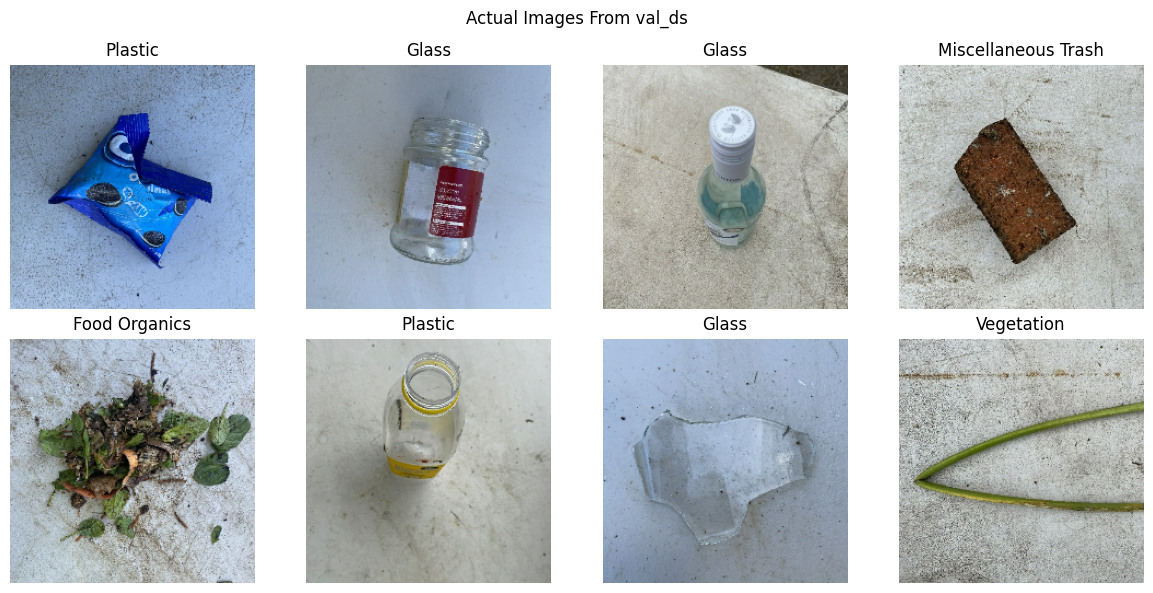

In [14]:
plt.figure(figsize=(12, 6))

for i in range(min(8, val_images.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(to_display_image(val_images[i], model_type))
    plt.title(data["class_names"][val_labels[i].numpy()])
    plt.axis("off")

plt.suptitle("Actual Images From val_ds")
plt.tight_layout()
plt.show()

## 11. Inspect The Actual train_ds Output

`train_ds` should have resize + preprocessing + augmentation.

In [15]:
train_images, train_labels = next(iter(data["train_ds"]))

print("train_ds image batch shape:", tuple(train_images.shape))
print("train_ds label batch shape:", tuple(train_labels.shape))
print("train_ds pixel min:", float(tf.reduce_min(train_images).numpy()))
print("train_ds pixel max:", float(tf.reduce_max(train_images).numpy()))

train_ds image batch shape: (32, 224, 224, 3)
train_ds label batch shape: (32,)
train_ds pixel min: 0.0
train_ds pixel max: 1.1742514371871948


- `train_ds` also has shape `(32, 224, 224, 3)`, so the training batches are built correctly.
- The max value can be a little under `1.0` after augmentation, which is normal.
- These images should show the real training pipeline output: resize + MobileNetV2 preprocessing + augmentation.

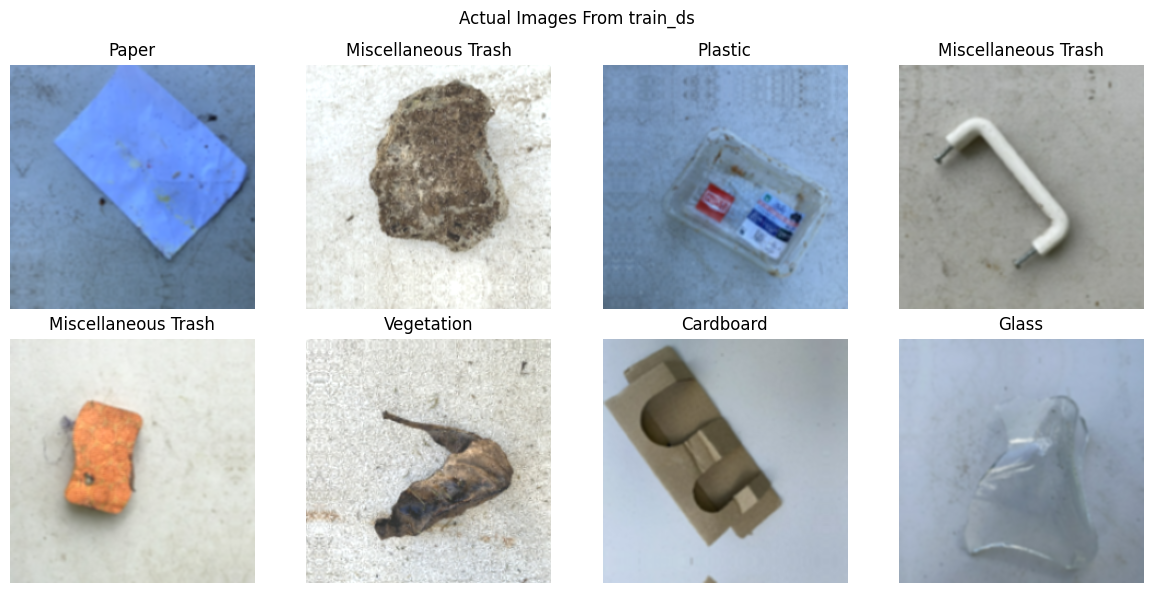

In [16]:
plt.figure(figsize=(12, 6))

for i in range(min(8, train_images.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(to_display_image(train_images[i], model_type))
    plt.title(data["class_names"][train_labels[i].numpy()])
    plt.axis("off")

plt.suptitle("Actual Images From train_ds")
plt.tight_layout()
plt.show()